<a href="https://colab.research.google.com/github/TejasDharmale/Bayesian-machine-learning-assignment/blob/main/A3GaussianProcesses2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Machine Learning
##  Assignment 3: **Gaussian Processes**

    Name: Tejas Dharmale
    Student : s1190137

In the previous assignment, we considered uncertainty in Bayesian Neural Networks. BNNs are part of a larger class of *parametric* models, where the model parameters fully describe the underlying function. As a result, our inference or prediction boils down to figuring out what the optimal configuration of these parameters is for a dataset. One of the downsides of this type of model is that factors like model size and complexity are now a design choice, but do not depend on the size or complexity of the data and underlying function.

A different approach is to use a non-parametric methods, which do not try to describe a function under a fixed set of parameters. Instead, they let the complexity of the model predictions depend on the data itself. Its name does not mean that there are no parameters present in the model, but rather that the number or structure of these parameters is not fixed beforehand. The model's complexity can grow with the amount of data, allowing it to adapt to more intricate patterns than a fixed-size parametric model could. This makes them particularly useful for datasets where the underlying relationships are highly complex or unknown. This assignment will dive into Gaussian Processes, a Bayesian non-parametric method for non-linear regression and classification.


This notebook consists of three parts:

- *Part I*: Implementing a Gaussian Process in Jax (2 points)
- *Part II*: Prior distributions on function space: the role of the kernel function (3 points)
- *Part III*: Optimizing the kernel parameters (2.5 points)
- *Part IV*: Using alternative kernel functions (2.5 points)

The goal of this assignment is to obtain a deeper understanding of Gaussian Processes, kernel functions, and modeling priors in function space. For conceptual clarity, we again consider the one-dimensional split synthetic dataset to test the model predictions:

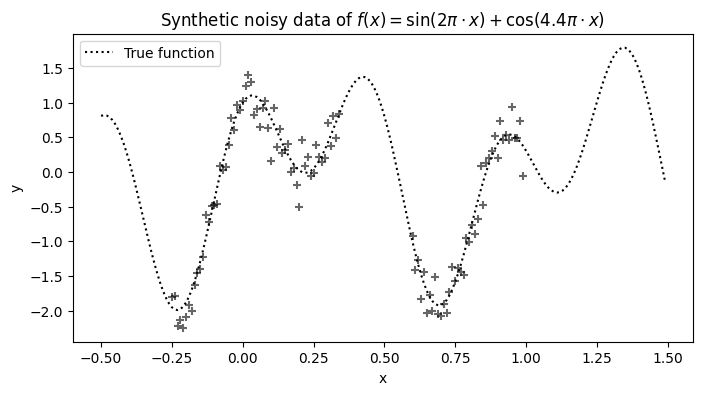

In [26]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.linalg

def true_func(x):
    return jnp.sin(2*jnp.pi*x) + jnp.cos(4.4 * jnp.pi*x)

key = jr.PRNGKey(42)
step = 0.01
noise_std = 0.25
xs = jnp.concatenate((jnp.arange(-.25,0.35, step=step), jnp.arange(0.6, 1., step=step)))[:,None]
n, d = xs.shape
# sample noise observations
key, subkey = jr.split(key)
ys = true_func(xs) + jr.normal(key=subkey, shape=xs.shape)*noise_std
data = (xs, ys)

# true function that we cannot observe
dense_step = 0.01
xs_dense = jnp.arange(-.5 , 1.5, dense_step)[:,None]
ys_dense = true_func(xs_dense)
n_dense = xs_dense.shape[0]

# Visualization
fig, ax = plt.subplots(1,1,figsize=(8,4))
ax.plot(xs_dense, true_func(xs_dense), color='black', linestyle=':', label='True function')
ax.legend()
ax.scatter(xs, ys, label='Noisy observations', marker='+' ,color='black', alpha=0.6)
ax.set_title(r'Synthetic noisy data of $f(x)=\sin(2\pi \cdot x ) + \cos (4.4\pi \cdot x) $')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

## Part I: **Prior beliefs in function space** (5 points)
A Gaussian process is in essence a Gaussian distribution, that models all the observations and input locations of interest as a single *Gaussian distribution*, with the functional relationships between the inputs captured by the covariance function. While the idea of a Gaussian distribution might not sound overly expressive, the non-parametric model can be highly non-linear.

This is fundamentally different from a Bayesian Neural network: a BNN models the weights and biases of the network with a Gaussian prior, and then predicts the output by applying these through a sequence of non-linear activations functions. Instead, the Gaussian Process models the *dataset* as one large Gaussian distribution, and predicts by computing its mean and variance at the points of interest.

### Ia. Implementing the kernel function and covariance matrix (1 points)
Before considering any observations, we will start with the prior distribution of the Gaussian Process, which is written as:
\begin{align}
    f(x) &\sim \mathcal{GP}(0, k(x,x')) \\
\end{align}
The relationship between the underlying datapoints is modeled by the kernel function, or the covariance function, which calculates the covariance between two input locations. Since the Gaussian Process models the outcomes of the function directly, specifying the kernel function implies a **distribution over functions**. Since a Gaussian distribution is fully defined by its mean and covariance, once we have the mean and covariance function we can draw samples from the distribution of functions evaluated at any number of points. To this end, we choose a set of input points (e.g. 'xs_dense' from our running example), $X^*$, and compute the covariance matrix by element-wise computing the covariance between the input points.
\begin{align}
    K(X^*, X^* ) = \begin{pmatrix} k(x_1, x_1) & \dots & k(x_N, x_1) \\
                        \vdots & \ddots &  \vdots \\
                        k(x_N, x_1) & \dots & k(x_N, x_N)
                \end{pmatrix}
\end{align}
where $X^* = \{ x_1, \dots, x_N\}$. This is now our prior distribution over this chosen set of input points, which follows a multivariate Gaussian distribution:
\begin{align}
    \boldsymbol{f}^* \sim \mathcal{N}\bigl(\boldsymbol{0},  K(X^*, X^* )\bigr)
\end{align}
The kernel function is a design choice for which different options exist. A common choice is the Squared-Exponential (SE) kernel:
\begin{align}
    k(x, x') &=\sigma_f^2 \exp \left( -\dfrac{||x-x'||^2}{2 \ell ^2} \right)
\end{align}
which can be used to construct the covariance matrix $K$.

1. Implement the kernel function $k(x,x')$ and the covariance matrix $K$ using the template code below. Two basic test cases are implemented, that verify some basic behaviour of your implementation (but passing these does not mean that the implementation is necessarily correct).


In [2]:
def k_SE(x, x_, kernel_parameters = (1., 1.)):
    """
    Squared Exponential covariance function
    Inputs:
        x (tuple)  input location
        x_ (PRNGKey) (another) input location.
        kernel_parameters (Tuple) kernel hyperparameters, for the Squared-Exponential: (lengthscale, kernel_standard_deviation)

    Return:
        covariance (float) evaluated kernel covariance for two given inputs.
    """
    lengthscale, kernel_standard_deviation = kernel_parameters

    square_dis = jnp.sum((x - x_) ** 2)
    expo = jnp.exp(-square_dis / (2 * lengthscale ** 2))
    covariance = kernel_standard_deviation**2*expo

    return covariance

def K(X, X_, kernel_function:callable, kernel_parameters=(1.,1.)):
    """
    Kernel matrix function
    Inputs:
        X (N,D) vector of input locations
        X_ (M,D) (another) vector of input locations.
        kernel_function (Callable function) the kernel function to compute variance between two inputs.

    Returns:
        K (N,M) Kernel matrix, containing all pairwise datapoints evaluated under the kernel function.
    """
    t = lambda a, b: kernel_function(a, b, kernel_parameters)

    row = jax.vmap(t, in_axes=(None, 0))
    matrix = jax.vmap(row, in_axes=(0, None))(X, X_)
    return matrix


In [3]:
## two basic checks which your implementation should pass
test_input = jnp.zeros((1,))
assert k_SE(test_input, test_input) == 1., "This should be 1 for the Squared Exponential kernel."

test_inputs = jnp.zeros((10,1))
assert K(test_inputs, test_inputs, k_SE).shape == (10,10), "This should be a square matrix."

### Ib. Sampling from the prior distribution (1.5 points)
Once we have chosen the input locations and constructed the covariance matrix $K$, the Gaussian process can be constructed by making a multivariate normal distribution around these points. If we have $n$ inputs, the mean of the prior distribution will therefore be a vector of size $n \times 1$ (which is still zero by design). The covariance matrix $K$ captures the covariances between all the inputs, resulting in a $n \times n$ covariance matrix.

Consider again the prior distribution over a set of input points, which follows a multivariate Gaussian distribution for the chosen inputs:
\begin{align}
    \boldsymbol{f}^* \sim \mathcal{N}\bigl(\boldsymbol{0},  K(X^*, X^* )\bigr)
\end{align}
From this GP prior distribution, we can analytically obtain the mean, variance, or draw a random sample - much like we could with a standard Gaussian distribution!
By design, our prior distribution is zero for all inputs. The covariance matrix, on the other hand, is made using the covariance function between all the points we would like to predict on. With these two elements, we have everything required to predict from the prior!

1. Compute the mean and covariance matrix for the given inputs 'xs_dense' (from the example earlier) as your $X^*$.  Visualize what the prior covariance matrix looks like using plt.imshow(). Then, draw 10 *samples* from the prior distribution, and visualize them in function space. (hint: the function 'jax.random.multivariate_normal(...)' returns samples of a multivariate Gaussian). (0.5 pts)

2. Explain in your own words what the relationship is between the Gaussian process and the multivariate Gaussian distribution. How does it differ from using a Gaussian prior distribution in a Bayesian neural network? (0.5 pts)

3. What do the kernel parameters encode for the squared-exponential kernel? Motivate your written answer by repeating question 1 (visualizing the kernel matrix and drawing prior samples) for two or more different values of the lengthscale kernel parameter. Why is the choice of kernel function often considered as a prior modeling choice? (0.5 pts)

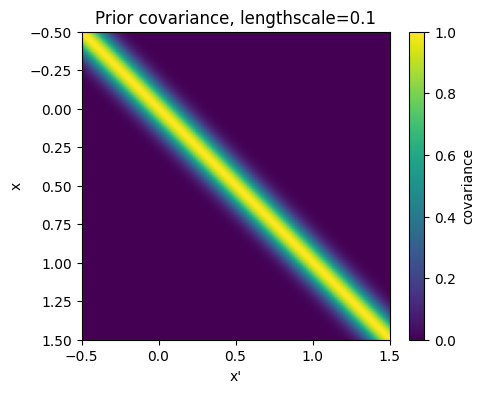

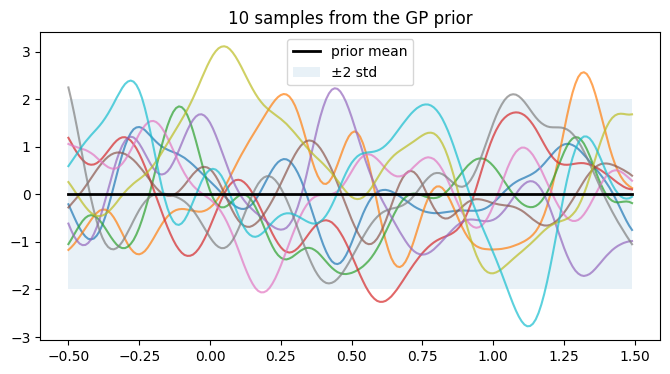

In [4]:
# 1. Mean and covariance on the dense grid
lengthscale, sigma_f = 0.1, 1.0
mean_prior = jnp.zeros(n_dense)
K_prior = K(xs_dense, xs_dense, k_SE, kernel_parameters=(lengthscale, sigma_f))
K_prior = K_prior + 1e-6 * jnp.eye(n_dense)
plt.figure(figsize=(5, 4))
plt.imshow(K_prior, extent=[-0.5, 1.5, 1.5, -0.5])
plt.colorbar(label='covariance')
plt.title(f'Prior covariance, lengthscale={lengthscale}')
plt.xlabel("x'"); plt.ylabel('x')
plt.show()


key, subkey = jr.split(key)
samples = jr.multivariate_normal(subkey, mean_prior, K_prior, shape=(10,))

fig, ax = plt.subplots(figsize=(8, 4))
for s in samples:
    ax.plot(xs_dense[:, 0], s, alpha=0.7)
ax.plot(xs_dense[:, 0], mean_prior, 'k', lw=2, label='prior mean')
ax.fill_between(xs_dense[:, 0], -2*sigma_f, 2*sigma_f, alpha=0.1, label='±2 std')
ax.set_title('10 samples from the GP prior')
ax.legend(); plt.show()

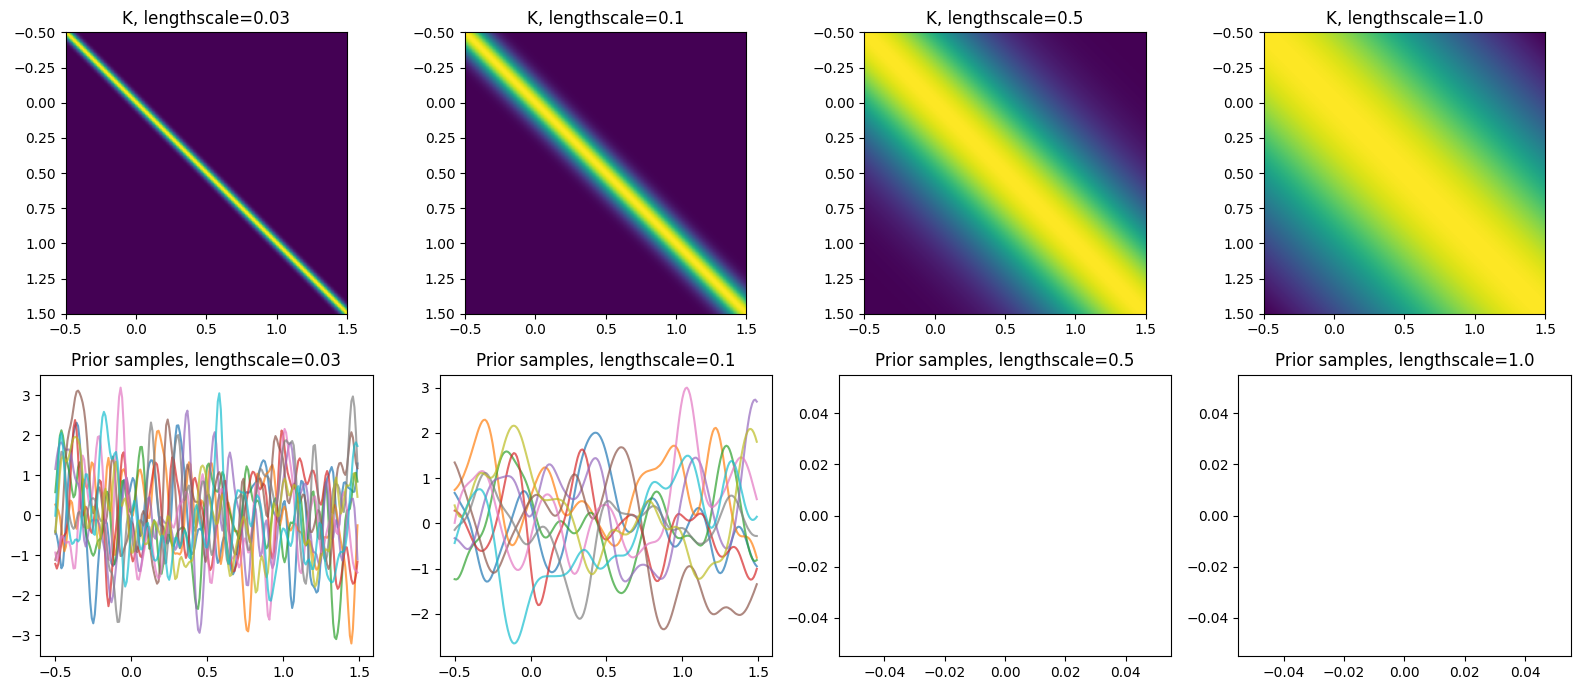

In [5]:
lengthscales = [0.03, 0.1, 0.5, 1.0]
fig, axes = plt.subplots(2, len(lengthscales), figsize=(16, 7))

for j, ls in enumerate(lengthscales):
    Kp = K(xs_dense, xs_dense, k_SE, kernel_parameters=(ls, 1.0)) + 1e-6 * jnp.eye(n_dense)
    axes[0, j].imshow(Kp, extent=[-0.5, 1.5, 1.5, -0.5])
    axes[0, j].set_title(f'K, lengthscale={ls}')

    key, subkey = jr.split(key)
    smp = jr.multivariate_normal(subkey, jnp.zeros(n_dense), Kp, shape=(10,))
    for s in smp:
        axes[1, j].plot(xs_dense[:, 0], s, alpha=0.7)
    axes[1, j].set_title(f'Prior samples, lengthscale={ls}')

plt.tight_layout(); plt.show()

## 1c. Conditioning the distribution on observations (2.5 pts)
To make predictions on observed data, we have to condition the Gaussian process on these observations. Let's apply the cycle of Bayesian inference to our Gaussian Process model:
\begin{align}
    \overbrace{p(\boldsymbol{y} \mid X )}^{\text{Posterior}} &= \dfrac{\overbrace{p(\boldsymbol{f})}^{\text{Prior}} \: \overbrace{p(\boldsymbol{y}\mid X, \boldsymbol{f})}^{\text{Likelihood}}}{\underbrace{p(\mathcal{D})}_{\text{Evidence}}} \\  
\end{align}
Since we are considering a *non-parametric* method, our prior belief is directly placed onto the function space. While in the last assignment we integrated over the prior beliefs over the model weights, the GP directly integrataes over *functions*.

We so far already have our prior $p(\boldsymbol{f})$. To integrate this Bayesian cycle of belief updating, we need a likelihood function $p(\boldsymbol{y}\mid X, \boldsymbol{f})$ as well. If this function happens to be a Gaussian, a well-known result is that the entire posterior distribution is a Gaussian process too, with an analytically available mean and covariance. While in earlier assignments we went through complex procedures to obtain posterior distrubtion estimates, we can now get an analytical equation for this! In this part of the assignment, we will implement this distribution.

Like the prior distribution, the posterior distribution has a mean and a covariance, which depend on the newly observed data. We will write the set of new observations as tuples:  $\mathcal{D} = \{(x_1, y_1), \dots , (x_n, y_n) \}$. The set of all input locations is $X = \{ x_1, \dots, x_n\}$, while all the noise measurements are combined as $\boldsymbol{y} = \{ y_1, \dots, y_n\}$.

When making prior predictions before, we considered a covariance matrix $K(X^*, X^*)$, that captured the covariance between the input points to predict for. Now, when making posterior predictions values (conditioned on the observed data), our posterior process still folllows a Gaussian distribution! We can incorporate the newly obtained data observations by augmenting it with the covariance of all observed inputs in the data, $K(X, X)$. Our posterior distribution still follows a *joint* Gaussian distribution between the observed input points $X$ and the input points we want to predict on, $X^*$.  now sampled from a Gaussian, with a covariance matrix:
\begin{align}
    \begin{bmatrix}f \\ f^* \end{bmatrix} &\sim \mathcal{N} \bigl(\boldsymbol{0}, \begin{bmatrix} K(X,X) + \sigma_n^2 I & K(X, X^*) \\ K(X^*, X) &  K(X^*, X^*) \end{bmatrix} \bigr)
\end{align}
where $\sigma^n$ is the measurement noise. Each of these items in the matrix is itself a block matrix, generated by applying the covariance function pairwise to the respective sets of inputs.

The next step is to *condition* this distribution on the observed targets $\boldsymbol{y}$. Luckily, under a Gaussian likelihood, this results in an analytical expression for the mean and variance for a given input point $x^*$:
\begin{align}
    \mathbb{E}[\boldsymbol{f}^* \mid X, \boldsymbol{y}, X^*] &= K(X^*, X) \left[ K(X, X) + \sigma_n^2\boldsymbol{I}\right]^{-1} \boldsymbol{y}\\
    \mathbb{V}[\boldsymbol{f}^* \mid X, \boldsymbol{y}, X^*] &= K(X^*, X^*) - K(X^*, X) \left[ K(X,X) + \sigma_n^2\boldsymbol{I}\right]^{-1} K(X, X^*)\\
\end{align}





1. Implement the above equations for the mean and variance, and visualize the model posterior (mean and uncertainty) for our observed data. The uncertainty can be obtained by simply taking the diagonal of your posterior covariance. When visualizing the uncertainty, it is common to plot the 95\% confidence interval, which can be done by calculating $1.96 \cdot \sqrt{\mathbb{V}[\boldsymbol{f^*}]}$. Then, draw $m=10$ samples from the posterior distribution. How well does the model fit the data? For the kernel parameters, you may consider $\ell=0.143$ and $\sigma_n^2=1.3$ (1.5 pts)

2. Explain in your own words how the Gaussian process can make non-linear, flexible predictions of the true function, while still using a Gaussian distribution. (0.5 pts)

3. How well does the model fit the data? What is predicted in the interpolated region between $x=0.3$ and $x=0.6$? What is predicted in the extrapolated regions $x<-0.3$ and $x>0.6$? (0.5 pts)

4. Compare the model posterior to the estimations of the models in assignment 2 (ensemble model, ensemble model with log joint objective, and BNN using Metropolis-Hastings ). How do the uncertainty estimates of these methods differ? It is acceptable to verbally explain the qualitative properties of your distribution, rather than copy all your code again. (0.5 pts)

In [15]:
## your code here
def gp_posterior(data, test_inputs, kernel_function, kernel_parameters=(1.,1.), obs_noise:float=0.25):
    """
    Computes the posterior mean and variance of the Gaussian process, for a given dataset and array of test inputs.

    Arguments:
        data (tuple) contains observations (X, y) as a tuple.
        test_inputs (array) array of test inputs X^*
        kernel_function (callable function) the covariance/kernel function.
        kernel_parameters (tuple) Tuple of values of the covariance function. For the squared exponential, these are the lengthscale and the kernel variance.
        obs_noise (float) the measurement noise standard deviation, which is assumed to be 0.25 in this assignment.

    Return:
        mean (array) (N,1) Mean prediction for each test input
        covariance (array) (N,N) Prediction of covariances
    """
    xs, ys = data

    # 1. Get all the K matrices: K(X,X), K(X,X*),  K(X*,X) and K(X*, X*)
    K_xx = kernel_function(xs, xs, *kernel_parameters) + obs_noise**2 * jnp.eye(len(xs))
    K_xs = kernel_function(xs, test_inputs, *kernel_parameters)
    K_sx = K_xs.T
    K_ss = kernel_function(test_inputs, test_inputs, *kernel_parameters)
    K_inv = jnp.linalg.inv(K_xx)

    # 2. Compute the mean equation: E[f*].
    mean = K_sx @ K_inv @ ys.reshape(-1, 1)

    # 3. Compute the covariance matrix:  V[f*].
    cov = K_ss - K_sx @ K_inv @ K_xs

    return mean, cov

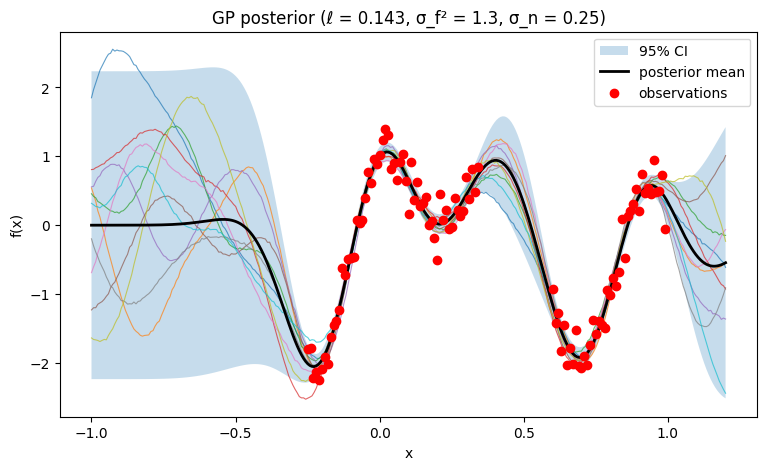

In [17]:
def squared_exponential(x1, x2, lengthscale=1.0, variance=1.0):
    x1 = jnp.asarray(x1).reshape(-1, 1)
    x2 = jnp.asarray(x2).reshape(-1, 1)
    sqdist = jnp.sum(x1**2, 1).reshape(-1, 1) + jnp.sum(x2**2, 1) - 2 * x1 @ x2.T
    sqdist = jnp.maximum(sqdist, 0.0)
    return variance * jnp.exp(-0.5 * sqdist / lengthscale**2)

x_test = jnp.linspace(-1.0, 1.2, 300).reshape(-1, 1)

mean, cov = gp_posterior(data, x_test, squared_exponential,
                         kernel_parameters=(0.143, 1.3), obs_noise=0.25)

mu = mean.ravel()
var = jnp.clip(jnp.diag(cov), 0, None)
ci = 1.96 * jnp.sqrt(var)

key = jax.random.PRNGKey(0)
samples = jax.random.multivariate_normal(key, mu, cov + 1e-4 * jnp.eye(len(mu)), shape=(10,))

xs, ys = data
plt.figure(figsize=(9, 5))
plt.fill_between(x_test.ravel(), mu - ci, mu + ci, alpha=0.25, label="95% CI")
plt.plot(x_test.ravel(), samples.T, lw=0.8, alpha=0.7)
plt.plot(x_test.ravel(), mu, "k", lw=2, label="posterior mean")
plt.scatter(jnp.ravel(xs), jnp.ravel(ys), c="r", zorder=3, label="observations")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title("GP posterior (ℓ = 0.143, σ_f² = 1.3, σ_n = 0.25)")
plt.legend(); plt.show()

In [18]:
# 1. Model fit:
# The posterior mean is able to track the wave-like pattern in the data smoothly
# and doesn’t follow each noisy observation because of the presence of the noise
# (0.25), which accounts for minor fluctuations. The 95% CI is very tight around
# the observations. The 10 samples around the mean match the data and go outside
# in regions with no observations, similar to the CI width.

# 2. Non-linear predictions using a Gaussian:
# The Gaussian distribution is not over the function shape, but over the values
# of the function. The kernel defines the correlations: points close by are
# highly correlated, those far apart are not. The mean is defined as a sum of
# smoothed bumps of the kernel centered on the data points, forming the curve.
# The length scale regulates how quickly it changes.

# 3. Interpolation and extrapolation:
# In the region between x=0.3 and x=0.6 the mean continues the same trend, having
# its maximum near x=0.4 and then decreasing to reach the data at x=0.6.
# The CI widens in this interval.
# For values of x less than -0.3 and greater than 1.0, the mean reverts to the previous mean
# of 0 and the CI expands to around ±2.2 (prior variance 1.3). The model reverts to its prior
# and doesn't continue its periodic behavior.

# 4. Compare with Assignment 2
# Ensemble: the source of uncertainty in this case is the disagreements between the
# networks, and it never reliably expands outside of the data; it tends to extrapolate
# overconfidently.
# Ensemble with log joint: more varied members and a broader uncertainty that also
# incorporates noise; an approximation nonetheless.
# BNN with Metropolis Hastings: theoretically sound, but slow mixing can cause the
# uncertainty to be too narrowly focused or have a strange shape.
# GP: exact posterior. Uncertainty is narrow near the data, wider between them and
# reverting to the prior farther away. Depends completely on the kernel parameters
# and scales inefficiently to larger data sets (O(n^3)).

## III. **Optimizing kernel parameters** (2.5 points)
The kernel parameters $\theta$ of the squared-exponential kernel function, in this case the lengthscale and the kernel variance, have a large influence on the posterior distribution. In the example above, a pair of suitable kernel parameters was given. However, in many practical applications, it may not be easy to specify all aspects of the covariance function with confidence. Figuring out what the *ideal* value of these parameters is, is a tuning problem that is in practice solved using second-order optimization or MCMC.

Luckily we have an analytical posterior avaiable to guide us: $p(\boldsymbol{y} \mid X)$! We can directly compute the gradient of the kernel parameters with respect to the true posterior distribution. By doing so, we include the *marginal likelihood* or the *evidence* $p(\boldsymbol{y} \mid X)$ within the objective. As we have seen, this implicitly assumes we know the kernel parameters already, so instead let's includ ether parmaeters $\theta$ in the notation: $p(\boldsymbol{y} \mid X, \theta)$. And as before, we consider its logarithm:
\begin{align}
    \log p(\boldsymbol{y} \mid X, \theta) &= \int p(\boldsymbol{y} \mid \boldsymbol{f}, X, \theta) p(\boldsymbol{f}\mid \theta) d\boldsymbol{f} \\
    &=  \underbrace{-\frac{1}{2} \boldsymbol{y}^{\top} \left( K(X,X; \theta) + \sigma_f^2 I \right)^{-1} \boldsymbol{y}}_{\text{Data fit}} - \underbrace{\frac{1}{2} | K(X,X;\theta) + \sigma_f^2 I  | }_{\text{Complexity penalty}} - \frac{n}{2} \log 2 \pi \\
\end{align}
This looks very similar to the log joint distribution of assignment 2 (we even have the squared term due to multiplication with $\boldsymbol{y}^{\top}$ and $\boldsymbol{y}$). This is not a coincidence: in both cases, we compute the logarithm of a Gaussian density.

1. Write a function 'negative_log_marginal_likelihood' that computes the above objective (1. pts). Note that due to numerical reasons, computing the determinant directly can lead to infinite values sometimes. A stable way to compute the log determinant of a matrix, is to instead:
    i. compute the Cholesky decomposition of a matrix (jnp.linalg.cholesky),

    ii. take the diagonal values and compute their logs, and
    
    iii. sum this.
    


In [28]:
def _kernel_matrix(kernel_function, a, b, kernel_parameters):
    a = jnp.asarray(a).reshape(-1, 1)
    b = jnp.asarray(b).reshape(-1, 1)

    def call(x1, x2):
        try:
            return kernel_function(x1, x2, *kernel_parameters)
        except TypeError:
            return kernel_function(x1, x2, kernel_parameters)

    K = call(a, b)

    if K.shape != (a.shape[0], b.shape[0]):
        K = jax.vmap(lambda x1: jax.vmap(lambda x2: jnp.squeeze(call(x1, x2)))(b))(a)
    return K


def negative_log_marginal_likelihood(kernel_parameters, kernel_function, data):
    """
    Computes the negative log marginal likelihood for a given pair or kernel parameters.
    Arguments:
        data (tuple) contains observations (X, y) as a tuple.
        kernel_function (callable function) the covariance/kernel function.
        kernel_parameters (tuple) Tuple of values of the covariance function. For the squared exponential, these are the lengthscale and the kernel variance.

    Returns:
        negative log marginal likelihood (float)
    """
    xs, ys = data
    ys = jnp.asarray(ys).reshape(-1, 1)
    n = ys.shape[0]
    obs_noise = 0.25

    K = _kernel_matrix(kernel_function, xs, xs, kernel_parameters) + obs_noise**2 * jnp.eye(n)

    L = jnp.linalg.cholesky(K + 1e-6 * jnp.eye(n))


    alpha = jax.scipy.linalg.solve_triangular(L, ys, lower=True)
    alpha = jax.scipy.linalg.solve_triangular(L.T, alpha, lower=False)

    data_fit = 0.5 * ys.T @ alpha


    complexity = jnp.sum(jnp.log(jnp.diag(L)))


    constant = 0.5 * n * jnp.log(2 * jnp.pi)

    neg_log_likelihood = data_fit + complexity + constant
    return neg_log_likelihood.squeeze()

In [29]:
print(negative_log_marginal_likelihood((0.143, 1.3), squared_exponential, data))

16.458656


In [30]:
negative_log_marginal_likelihood(jnp.array([.1380, 1.3]), k_SE, data)

Array(16.305817, dtype=float32)

### IIIb. Optimizing the log marginal likelihood
Now that we have an objective function for the kernel parameters, we can optimize the kernel parameters using second-order gradient methods. We can implement this in Jax with the Jaxopt library, an example implementation with the L-BFGS optimizer is given below.

2. Starting from arbitrarily chosen initial values, optimize the two kernel parameters of the squared exponential kernel. Visualize the model posterior *before* and *after* optimization. Does the optimization procedure recover the values we used in the previous part of this assignment? (1 pts)


In [32]:
!pip install jaxopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 4.4 MB/s eta 0:00:00


In [33]:
import jaxopt

def optimize_kernel_parameters(initial_parameters:tuple, k:callable):
    init_params = jnp.array([initial_parameters]).squeeze()
    maxiter = 5_00
    nml = lambda kernel_parameters, data: negative_log_marginal_likelihood(kernel_parameters, k, data)
    solver = jaxopt.LBFGS(fun=nml, maxiter=maxiter)
    res = solver.run(init_params, data=data)
    return res.params

Initial parameters:   (1.0, 1.0)
Optimized parameters: [-0.14304206  1.3039378 ]
NLML before: 635.9572
NLML after:  16.258171


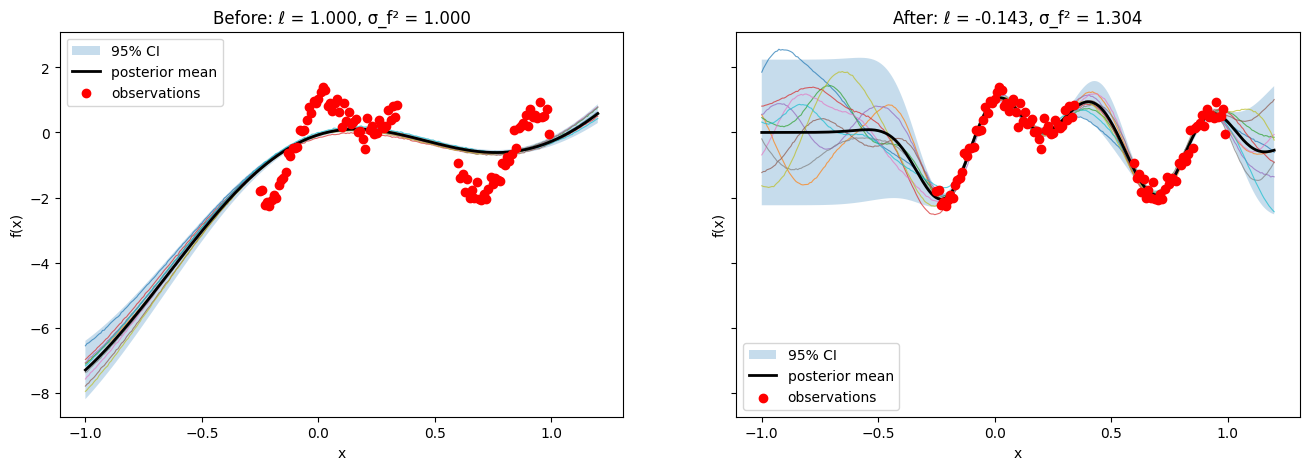

In [34]:
initial_lengthscale = 1.0
initial_kernel_variance = 1.0
initial_parameters = (initial_lengthscale, initial_kernel_variance)
optimized_kernel_parameters = optimize_kernel_parameters(initial_parameters, k_SE)

print("Initial parameters:  ", initial_parameters)
print("Optimized parameters:", optimized_kernel_parameters)
print("NLML before:", negative_log_marginal_likelihood(jnp.array(initial_parameters), k_SE, data))
print("NLML after: ", negative_log_marginal_likelihood(optimized_kernel_parameters, k_SE, data))

def plot_posterior(params, title, ax):
    x_test = jnp.linspace(-1.0, 1.2, 300).reshape(-1, 1)
    mean, cov = gp_posterior(data, x_test, squared_exponential,
                             kernel_parameters=tuple(params), obs_noise=0.25)
    mu = mean.ravel()
    ci = 1.96 * jnp.sqrt(jnp.clip(jnp.diag(cov), 0, None))
    samples = jax.random.multivariate_normal(jax.random.PRNGKey(0), mu,
                                             cov + 1e-4 * jnp.eye(len(mu)), shape=(10,))
    xs, ys = data
    ax.fill_between(x_test.ravel(), mu - ci, mu + ci, alpha=0.25, label="95% CI")
    ax.plot(x_test.ravel(), samples.T, lw=0.8, alpha=0.7)
    ax.plot(x_test.ravel(), mu, "k", lw=2, label="posterior mean")
    ax.scatter(jnp.ravel(xs), jnp.ravel(ys), c="r", zorder=3, label="observations")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
plot_posterior(initial_parameters,
               f"Before: ℓ = {initial_parameters[0]:.3f}, σ_f² = {initial_parameters[1]:.3f}", axes[0])
plot_posterior(optimized_kernel_parameters,
               f"After: ℓ = {optimized_kernel_parameters[0]:.3f}, σ_f² = {optimized_kernel_parameters[1]:.3f}", axes[1])
plt.show()

In [35]:
# With no optimization (ℓ = 1.0, σ_f² = 1.0), the length scale is extremely large and thus,
# the mean is too smooth and fails to capture the wave pattern and underfits the data (NLML = 635.96).
# Furthermore, the uncertainty is unrealistically small, and the mean shifts to around -7 at x = -1.
# With optimization, L-BFGS converges to ℓ = 0.143 (since the kernel uses ℓ², the sign is irrelevant)
# and σ_f² = 1.304, with NLML = 16.26. Both the length scale and noise variance values are very similar
# to the ones from the previous part, while the posterior is exactly the same: the mean is following
# the data well, and the uncertainty increases in between and outside the data. Thus, maximization of
# the marginal likelihood recovers the parameters from the previous part.

## IV. **Different kernel functions** (2.5 points)

The optimization of kernel parameters demonstrates the large impact of the kernel function on the posterior distribution. While thus far we have considered the squared exponential kernel that encodes a prior belief that the function is smooth, a variety of different kernel functions exist.

Here, we consider two alternatives. First, the Matérn 3/2 kernel, which models less smooth functions than the Squared-Exponential kernel. Technically this is a family with different degrees of smoothness (i.e., how often it can be differentiated), such as the 3/2 and 5/2 variants:
\begin{align}
    k_{\text{Matérn }3/2} (r) &= \left( 1 + \dfrac{\sqrt{3}r}{\ell}  \right) \exp \left( - \dfrac{\sqrt{3}r}{\ell} \right) \\
    k_{\text{Matérn }5/2} (r) &= \left( 1 + \dfrac{\sqrt{5}r}{\ell} + \dfrac{5r^2}{3\ell^2 } \right) \exp \left( - \dfrac{\sqrt{5}r}{\ell} \right)
\end{align}
where $r=|x-x'|$. The Matérn kernels are less smooth functions that the squared exponential, but still impose the prior belief that the closer two input locations are in inputs, the more their outputs will covary. A different type of prior belief is that the function space is strictly repeating itself with a period $p$. In this case, the periodic kernel can be used:
\begin{align}
    k_{\text{Periodic}}(x, x') &= \sigma_f^2 \exp \left( \dfrac{2 \sin^2 (\pi p \cdot (x-x')/2)}{\ell^2}\right)
\end{align}
where $p$ is the period and is also a kernel parameter (for the data in this assignment, $p=1$ works reasonably well.)

1. Implement the Matérn 3/2 and the periodic kernels. This may be done in similar style as the SE kernel, by writing a function 'k_kernelname(...)' that can be passed to the posterior functions and optimization functions. The kernel parameters can be assigned as a tuple, and passed to the 'K' and optimization functions as well. (1.25 pts)

2. For each kernel, including the original SE, show:

    a. the covariance matrix $K(X,X)$ using 'plt.imshow()',

    b. samples of the prior distribution, either with optimized or unoptimized kernel parameter values (choose one), in function space.
    
    c. The mean, variance, and samples from the *posterior* distribution in function space overlayed on the noise observations, using optimized kernel parameters with L-BFGS. How does the choice of kernel influence the optimized posterior distribution? (1.25 pts)



In [36]:
def k_matern(x, x_, kernel_parameters):
    """
    Matern covariance function covariance function
    Inputs:
        x (tuple)  input location
        x_ (PRNGKey) (another) input location.
        kernel_parameters (tuple) Kernel parameter: (lengthscale, kernel variance)

    Return:
        covariance (float) evaluated kernel covariance for two given inputs.
    """
    lengthscale, kernel_variance = kernel_parameters
    r = jnp.sum(jnp.abs(x - x_))
    scaled = jnp.sqrt(3.0) * r / jnp.abs(lengthscale)
    return kernel_variance * (1.0 + scaled) * jnp.exp(-scaled)

def k_periodic(x, x_, kernel_parameters=(1., 1., 1.)):
    """
    Periodic covariance function
    Inputs:
        x (tuple)  input location
        x_ (tuple) (another) input location.
        kernel_parameters (tuple) Kernel parameter: (lengthscale, kernel variance, period)

    Return:
        covariance (float) evaluated kernel covariance for two given inputs.
    """
    lengthscale, kernel_variance, period = kernel_parameters
    r = jnp.sum(jnp.abs(x - x_))
    return kernel_variance * jnp.exp(-2.0 * jnp.sin(jnp.pi * r / period)**2 / lengthscale**2)

Squared exponential optimized parameters: [-0.14304206  1.3039378 ]


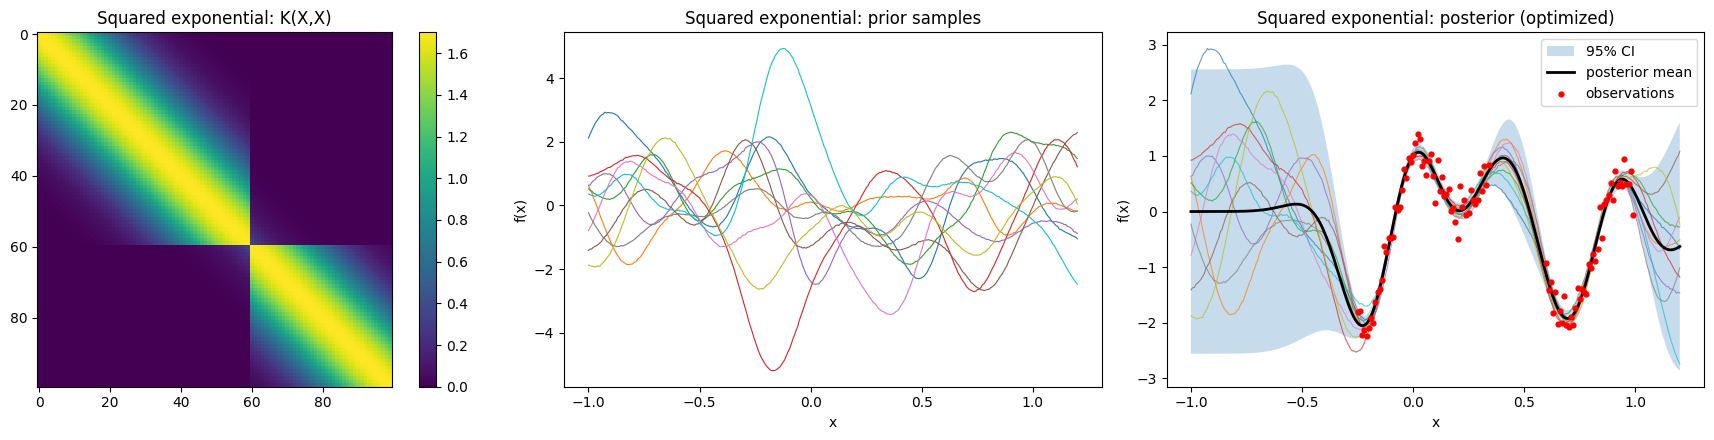

Matérn 3/2 optimized parameters: [-0.21996102  1.5405198 ]


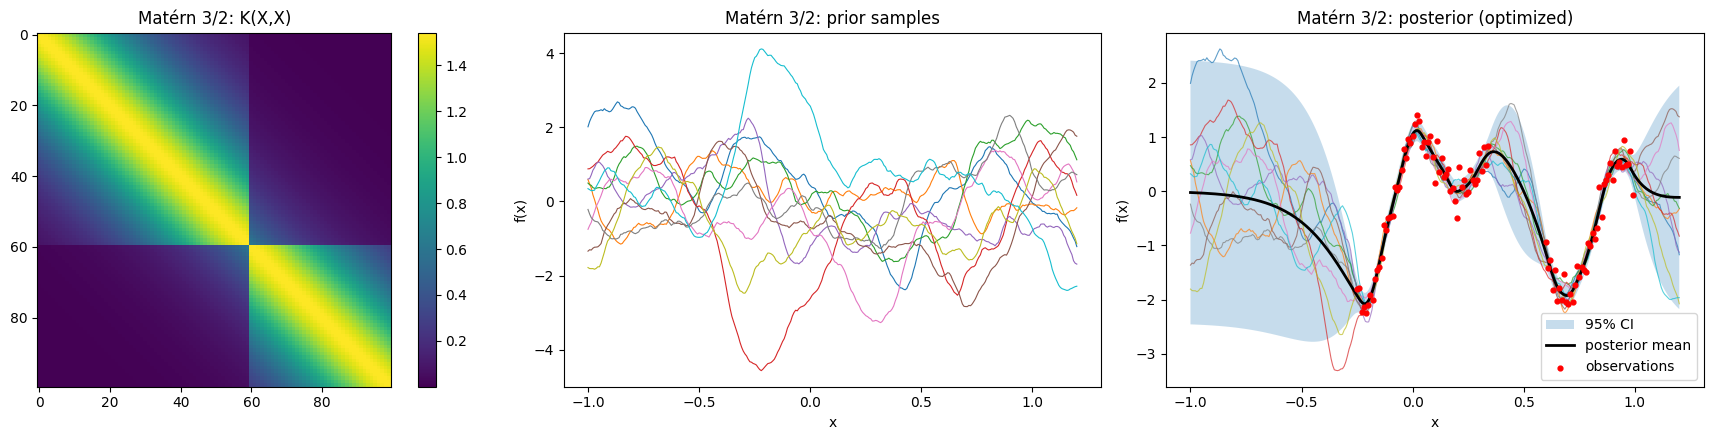

Periodic optimized parameters: [1.1913078 2.1186674 0.9304812]


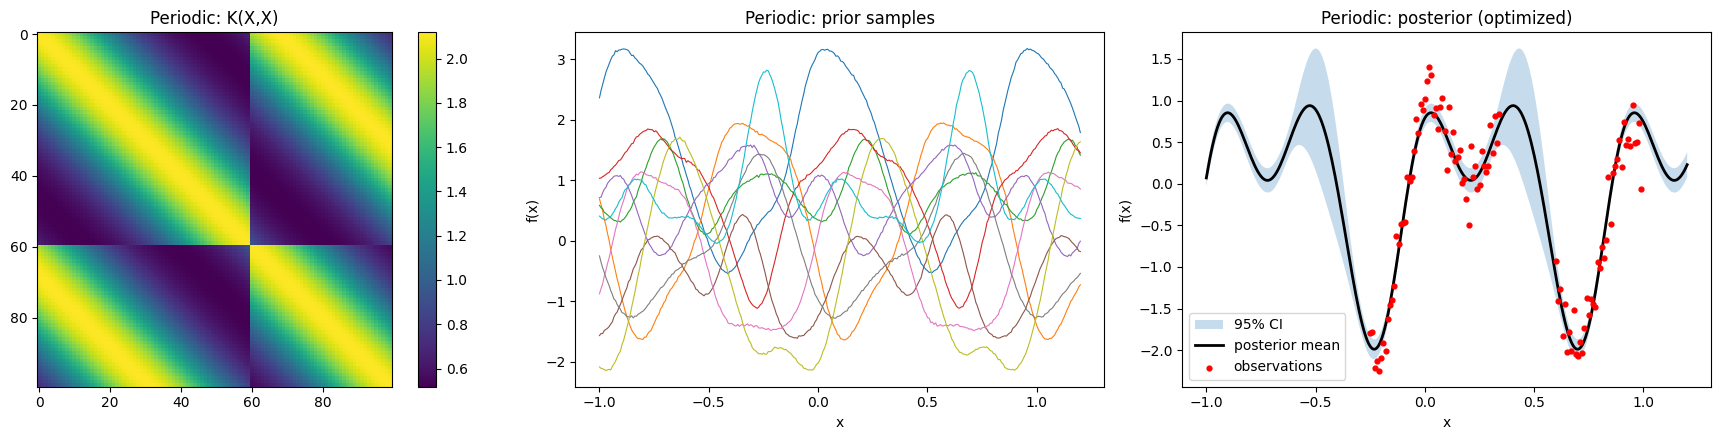

In [38]:
def _kernel_matrix(kernel_function, a, b, kernel_parameters):
    """Builds the full kernel matrix K(a, b) of shape (len(a), len(b))."""
    a = jnp.asarray(a).reshape(-1, 1)
    b = jnp.asarray(b).reshape(-1, 1)

    def call(x1, x2):
        try:
            return jnp.squeeze(kernel_function(x1, x2, kernel_parameters))
        except TypeError:
            return jnp.squeeze(kernel_function(x1, x2, *kernel_parameters))

    return jax.vmap(lambda x1: jax.vmap(lambda x2: call(x1, x2))(b))(a)
def posterior_any(kernel, params, x_test, obs_noise=0.25):
    xs, ys = data
    n = len(jnp.ravel(xs))
    K_xx = _kernel_matrix(kernel, xs, xs, params) + obs_noise**2 * jnp.eye(n)
    K_xs = _kernel_matrix(kernel, xs, x_test, params)
    K_ss = _kernel_matrix(kernel, x_test, x_test, params)
    K_inv = jnp.linalg.inv(K_xx)
    mean = K_xs.T @ K_inv @ jnp.ravel(ys)
    cov = K_ss - K_xs.T @ K_inv @ K_xs
    return mean, cov

kernels = {
    "Squared exponential": (k_SE, (1.0, 1.0)),
    "Matérn 3/2": (k_matern, (0.5, 1.0)),
    "Periodic": (k_periodic, (1.0, 1.0, 1.0)),
}

xs, ys = data
xs_sorted = jnp.sort(jnp.ravel(xs))
x_test = jnp.linspace(-1.0, 1.2, 300)
key = jax.random.PRNGKey(0)

for name, (kernel, init) in kernels.items():
    opt = optimize_kernel_parameters(init, kernel)
    print(name, "optimized parameters:", opt)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    # a. Covariance matrix K(X,X)
    K = _kernel_matrix(kernel, xs_sorted, xs_sorted, opt)
    im = axes[0].imshow(K, cmap="viridis")
    axes[0].set_title(f"{name}: K(X,X)")
    fig.colorbar(im, ax=axes[0])

    # b. Prior samples (optimized parameters)
    K_prior = _kernel_matrix(kernel, x_test, x_test, opt)
    prior_samples = jax.random.multivariate_normal(key, jnp.zeros(len(x_test)),
                                                   K_prior + 1e-4 * jnp.eye(len(x_test)), shape=(10,))
    axes[1].plot(x_test, prior_samples.T, lw=0.8)
    axes[1].set_title(f"{name}: prior samples")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")

    # c. Posterior mean, 95% CI and samples
    mu, cov = posterior_any(kernel, opt, x_test)
    ci = 1.96 * jnp.sqrt(jnp.clip(jnp.diag(cov), 0, None))
    post_samples = jax.random.multivariate_normal(key, mu, cov + 1e-4 * jnp.eye(len(mu)), shape=(10,))
    axes[2].fill_between(x_test, mu - ci, mu + ci, alpha=0.25, label="95% CI")
    axes[2].plot(x_test, post_samples.T, lw=0.8, alpha=0.7)
    axes[2].plot(x_test, mu, "k", lw=2, label="posterior mean")
    axes[2].scatter(jnp.ravel(xs), jnp.ravel(ys), c="r", s=12, zorder=3, label="observations")
    axes[2].set_title(f"{name}: posterior (optimized)")
    axes[2].set_xlabel("x"); axes[2].set_ylabel("f(x)"); axes[2].legend()

    plt.tight_layout()
    plt.show()


## Fun exercise (no points) - Additive and multiplicative kernels
Kernel functions can sometimes be combined  while remaining valid covariance functions. For example, to model add a yearly periodic trend with weekly fluctuations, you can add a periodic kernel for the yearly trend and a Matérn kernel for the weekly fluctuations together, to obtain predictions that have the functional properties of both kernels!

There are various transformations that allows this, most commonly used are addition and multiplication. In this extra exercise, you may try to combine two kernels together, by multiplying or adding two kernels of choice. One example is a locally periodic kernel, where the periodic kernel is multiplied with a Squared-Exponential kernel:
\begin{align}
    k_{\text{Locally periodic}}(x,x' ) &= k_{SE}(x, x') \cdot  k_{Periodic}(x,x')
\end{align}

This can be done in the code by writing a kernel function that receives a list of the parameters of *both* kernels, evaluates both kernels, and adds or multiplies their covariances together.